In [1]:
import pandas as pd

from src.preprocess.model import StorageStaticParams

## Prepare Input Parameters

In [2]:
from src.preprocess.load import load_input_data
from pathlib import Path
from src.preprocess.config import Configuration

config = '/Users/maciek/personal-projects/sopt/src/assets/config.ini'
configuration = Configuration.load(Path(config))
input_data = load_input_data(configuration)


In [3]:
partitions = pd.date_range(
    start=pd.Timestamp('2025-01-01'),
    end=pd.Timestamp('2025-12-31'),
)

## Run Optimization

In [ ]:
from src.postprocess.opt_results import OptResults
from src.opt.engine import Engine

results = dict()
for partition in partitions:
    input_data.params.partition = partition
    engine = Engine(input_data)
    engine.build()
    engine.optimize()
    results[partition] = OptResults.from_engine(engine)

In [5]:
revenue = pd.Series({p: results[p].obj for p in partitions})
y_revenue = float(revenue.sum())
y_revenue

692129.0674723345

## COMPUTE NPV (the simplest assumption)

<Axes: >

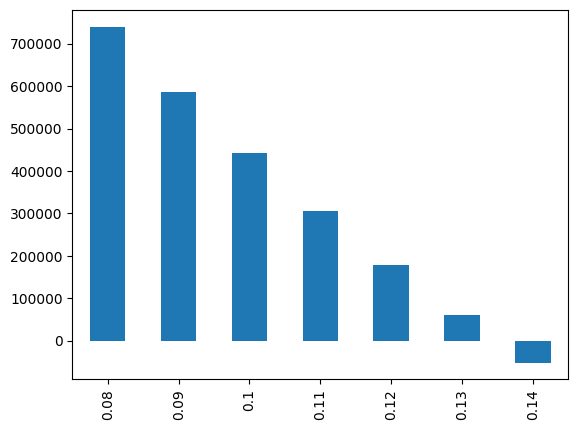

In [ ]:
def compute_npv(
    storage_params: StorageStaticParams,
    base_y_rev: float,
    wacc: float,
    deg_rate: float = 0.03,
) -> float:

    capex = storage_params.capex
    opex = storage_params.opex
    capacity = storage_params.capacity
    life_time = storage_params.lifetime_years

    total_capex = capacity * capex

    npv = -total_capex

    for y in range(1, life_time + 1):

        discount = (1 + wacc) ** (-y)
        degradation = (1 - deg_rate) ** (y - 1)

        revenue = base_y_rev * degradation
        yearly_opex = capacity * opex

        npv += discount * (revenue - yearly_opex)

    return npv

wacc_values = [0.08 + 0.01 * i for i in range(7)]
npv = [
    compute_npv(input_data.storage_static_params, base_y_rev=y_revenue, wacc=wacc)
    for wacc in wacc_values
]

pd.Series(data=npv, index=wacc_values).plot.bar()

## Initial Conclusion

For conservative parameters, it seems that the NPV for the energy storage in Poland is positive.
Next steps 
- compute the revenue per cycle 
- estimate the lambda coef
- modify obj and validate if the revenue per cycle will improve 

Revenue per year might be lower, but I am aiming in sth like: 
- use storage when the revenue per cycle is high enough, 
- if it is too low, try to use other markets, like the elasticity market